In [1]:
import sys
import pandas as pd
import numpy as np
import torch

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments    
)

import matplotlib.pyplot as plt

# Adiciona o diretório src ao path de forma mais robusta
sys.path.insert(0, '../')

from src import RepositorioDados
from src import evaluate_and_visualize

# Detecta o dispositivo e a precisão usada nas operações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu | Precision: torch.float32


In [2]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'timestamp'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
ID_COLUMNS = []             # Sem IDs (série única)

FORECAST_HORIZON = 1        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

Carregando modelo: context256_lags3_useTrue_v2
Configurações extraídas - Context Length: 256, Lags: 3, Use Mean Features: False
Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade



=== Scratch ===
MSE: 8.104969e-07
MAE: 3.565865e-04
RMSE: 9.002760e-04
MAPE: 7.819422e+01


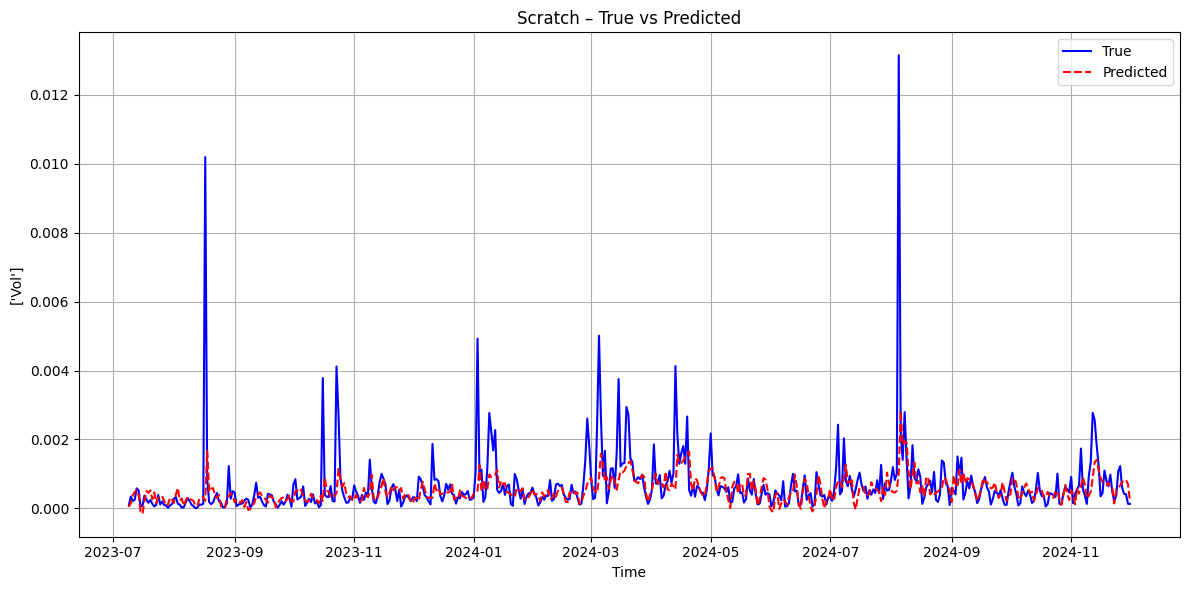

Carregando modelo: context256_lags5_useFalse
Configurações extraídas - Context Length: 256, Lags: 5, Use Mean Features: False
Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade



=== Scratch ===
MSE: 8.078752e-07
MAE: 3.659714e-04
RMSE: 8.988188e-04
MAPE: 9.039714e+01


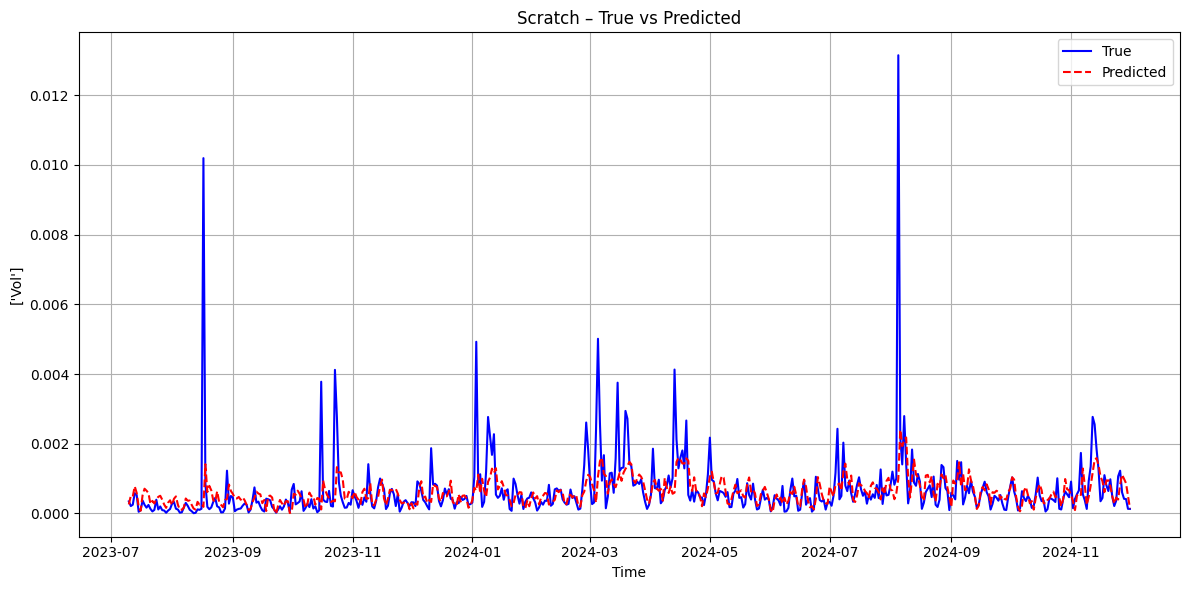

In [3]:
import os

modelos = os.listdir('../models/patchtst')
repo = RepositorioDados()

def parse_model_name(model_name):
    base_name = model_name.split('_v')[0]
    parts = base_name.split('_')
    context_length = int(parts[0].replace('context', ''))
    lags = int(parts[1].replace('lags', ''))
    use_mean_features = parts[2].replace('use_mean_features', '') == 'True'
    return context_length, lags, use_mean_features

def get_model(model_name):
    model_path = f'../models/patchtst/{model_name}'
    print(f"Carregando modelo: {model_name}")
    config = PatchTSTConfig.from_pretrained(model_path)

    model = PatchTSTForPrediction.from_pretrained(
        model_path,
        config=config,
        local_files_only=True,
        dtype=dtype
).to(device)

    model.eval()

    context_length, lags, use_mean_features = parse_model_name(model_name)
    print(f"Configurações extraídas - Context Length: {context_length}, Lags: {lags}, Use Mean Features: {use_mean_features}")

    repo = RepositorioDados()
    tsp, _, _, test_ds, _, _, _ = repo.executar(timestamp_col=TIMESTAMP_COLUMN, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC, context_length=context_length, target_col=TARGET_COLUMN, id_columns=ID_COLUMNS, forecast_horizon=FORECAST_HORIZON, use_mean_features=use_mean_features, lags=lags)

    test_df = test_ds.datasets[0].data_df

    forecast, results, labels, preds = evaluate_and_visualize(
        model=model,
        test_dataset=test_ds,
        tsp=tsp,
        test_df=test_df,
        timestamp_col=TIMESTAMP_COLUMN,
        target_column=TARGET_COLUMN,
        context_length=context_length,
        model_name="Scratch"
        )

    return forecast, results, labels, preds

results = []
results += list(map(get_model, modelos))

In [4]:
forecast = results[0][0]

Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade
Avaliando modelo HAR...

=== AVALIAÇÃO FINAL - LinearRegression (HAR) ===

TESTE:
  MSE: 8.990969e-07
  MAE: 5.051421e-04
  RMSE: 9.482072e-04
  MAPE: 2.020033e+02

Visualizando previsões no conjunto de teste...


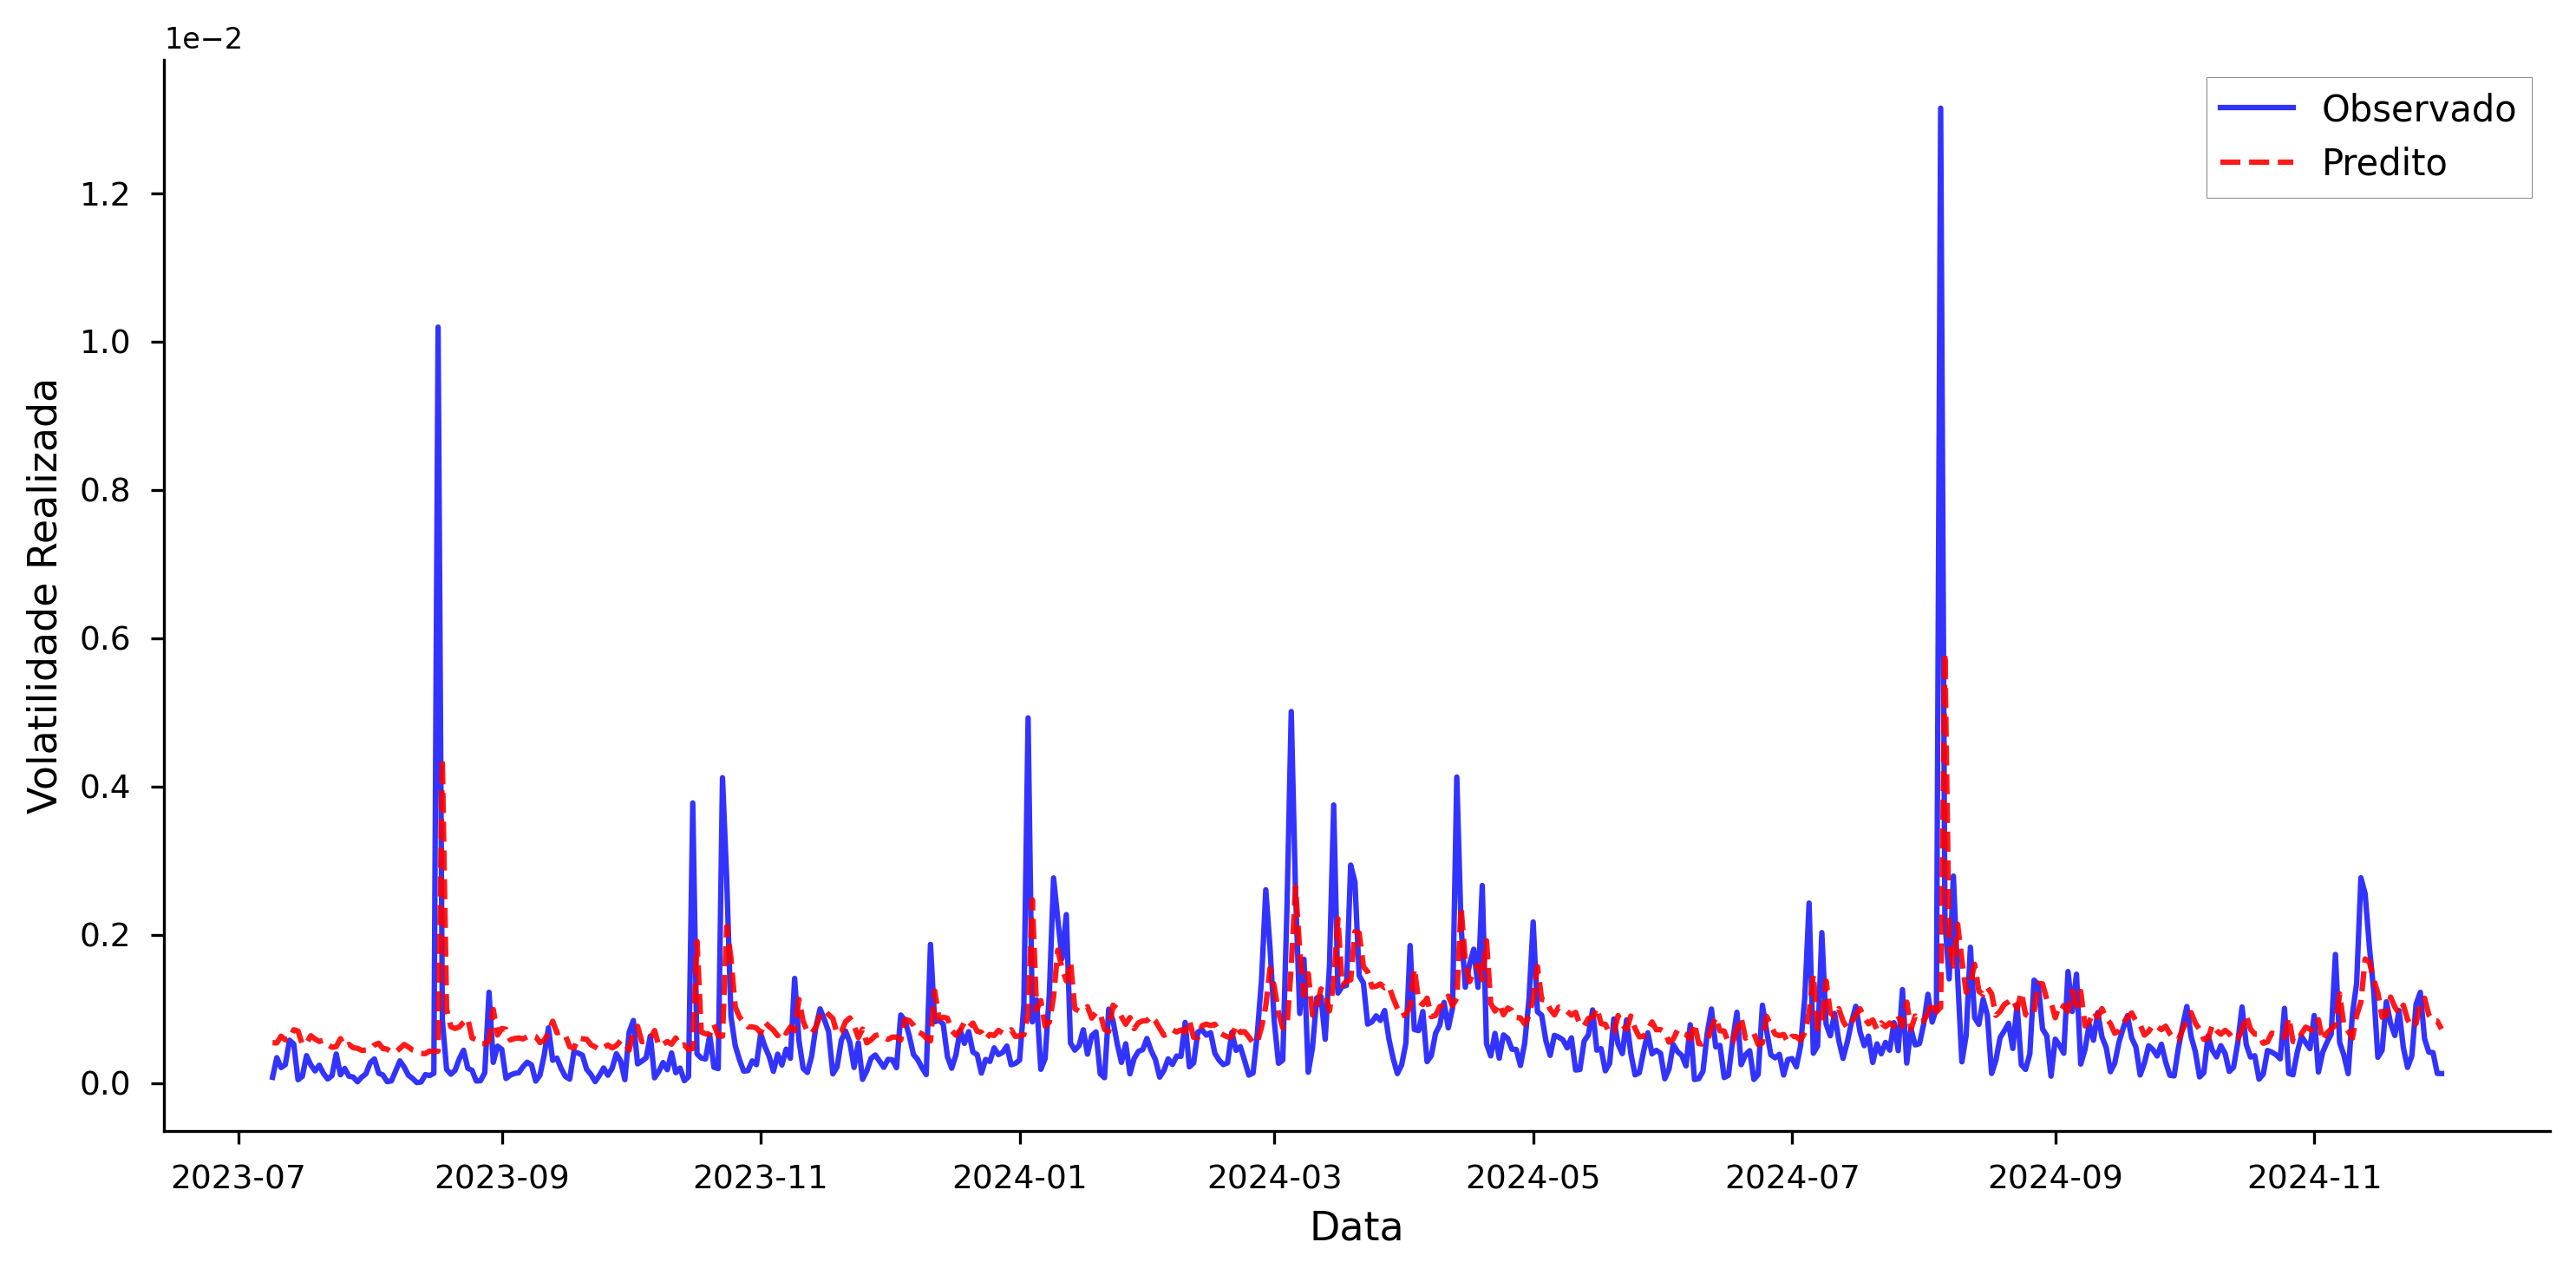

In [5]:
from src import HarModel, BTC_DATA_FILE

repo = RepositorioDados()
df_har = repo.load_and_prepare_data(file_path=BTC_DATA_FILE, timestamp_col=TIMESTAMP_COLUMN)
df_har = repo.calculate_features(df_har, timestamp_col=TIMESTAMP_COLUMN, lags=1, use_mean_features=True)

print("Avaliando modelo HAR...")
test_df = df_har[df_har[TIMESTAMP_COLUMN].isin(forecast)]

X_train = df_har[~df_har[TIMESTAMP_COLUMN].isin(forecast)].drop(['timestamp', 'Vol'], axis=1).values
y_train = df_har.loc[~df_har[TIMESTAMP_COLUMN].isin(forecast), TARGET_COLUMN].values

X_test = df_har[df_har[TIMESTAMP_COLUMN].isin(forecast)].drop(['timestamp', 'Vol'], axis=1).values
y_test = df_har.loc[df_har[TIMESTAMP_COLUMN].isin(forecast), TARGET_COLUMN].values
test_dates = df_har.loc[df_har[TIMESTAMP_COLUMN].isin(forecast), TIMESTAMP_COLUMN].values

har = HarModel()
har.train(X_train, y_train)

y_pred_train = har.predict(X_train)
y_pred_test  = har.predict(X_test)

har_metrics, har_labels, har_preds = har.evaluate_and_visualize(
    y_test, y_pred_test,
    test_dates=test_dates
)

In [6]:
# ==================== CARREGAR MODELO PRÉ-TREINADO ====================

BASE_MODEL = "ibm-granite/granite-timeseries-patchtst"

# Configuração: adapta modelo genérico para seu dataset
config = PatchTSTConfig.from_pretrained(BASE_MODEL)
config.num_input_channels = len(TARGET_COLUMN)  # 1 feature (Vol)

# Carrega weights pré-treinados
model_zero = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config
).to(device).to(dtype)

print(f"Modelo carregado: {BASE_MODEL}")
print(f"Num parâmetros: {model_zero.num_parameters():,}")

Modelo carregado: ibm-granite/granite-timeseries-patchtst
Num parâmetros: 614,496


In [7]:
repo_zero = RepositorioDados()
tsp_zero, train_ds_zero, valid_ds_zero, test_ds_zero, train_df_zero, valid_df_zero, test_df_zero = repo_zero.executar(timestamp_col=TIMESTAMP_COLUMN, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC, context_length=512, target_col=TARGET_COLUMN, id_columns=ID_COLUMNS, forecast_horizon=96, use_mean_features=True, lags=3)

tsp_zero_5, train_ds_zero_5, valid_ds_zero_5, test_ds_zero_5, train_df_zero_5, valid_df_zero_5, test_df_zero_5 = repo_zero.executar(timestamp_col=TIMESTAMP_COLUMN, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC, context_length=512, target_col=TARGET_COLUMN, id_columns=ID_COLUMNS, forecast_horizon=96, use_mean_features=False, lags=5)

Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade
Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def inverse_transform_targets_zero(tsp, values, target_column):
    scaler = next(iter(tsp.target_scaler_dict.values()))
    mean = scaler.mean_[0]
    std = scaler.scale_[0]
    return values * std + mean


# ============================================================
# Avaliação + Plot
# ============================================================

def evaluate_and_visualize_zero(
    model,
    test_dataset,
    tsp,
    test_df,
    timestamp_col,
    target_column,
    context_length,
    forecast,
    model_name="Modelo",
):
    # Predict
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="metric_temp",
            per_device_eval_batch_size=32,
            label_names=["future_values"]
        )
    )

    outputs = trainer.predict(test_dataset)

    preds = outputs.predictions
    labels = outputs.label_ids

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.array(preds)
    labels = np.array(labels)

    # Padroniza shape
    if preds.ndim == 2:
        preds = preds[..., None]
        labels = labels[..., None]

    # Desnormalização
    preds_real = inverse_transform_targets_zero(tsp, preds, target_column)
    labels_real = inverse_transform_targets_zero(tsp, labels, target_column)

    # 1-step de cada janela
    preds_first = preds_real[:, 0, 0]
    labels_first = labels_real[:, 0, 0]

    # Parte final da última janela (multi-step)
    tail_steps = max(forecast - 1, 0)
    preds_tail = preds_real[-1, 1 : 1 + tail_steps, 0] if tail_steps else np.array([])
    labels_tail = labels_real[-1, 1 : 1 + tail_steps, 0] if tail_steps else np.array([])

    # Concatena 1-step de cada janela + resto da última
    preds_full = np.concatenate([preds_first, preds_tail])
    labels_full = np.concatenate([labels_first, labels_tail])

    # Datas alinhadas
    dates = test_df[timestamp_col].values
    dates_first = dates[context_length : context_length + len(preds_first)]
    tail_start = context_length + len(preds_first)
    dates_tail = dates[tail_start : tail_start + len(preds_tail)]
    forecast_dates_full = np.concatenate([dates_first, dates_tail])

    # Métricas
    metrics_first = {
        "MSE": mean_squared_error(labels_first, preds_first),
        "MAE": mean_absolute_error(labels_first, preds_first),
        "RMSE": np.sqrt(mean_squared_error(labels_first, preds_first)),
        "MAPE": np.mean(
            np.abs((labels_first - preds_first) / (np.abs(labels_first) + 1e-8))
        ) * 100
    }
    metrics_full = {
        "MSE": mean_squared_error(labels_full, preds_full),
        "MAE": mean_absolute_error(labels_full, preds_full),
        "RMSE": np.sqrt(mean_squared_error(labels_full, preds_full)),
        "MAPE": np.mean(
            np.abs((labels_full - preds_full) / (np.abs(labels_full) + 1e-8))
        ) * 100
    }

    print(f"\n=== {model_name} ===")
    print("1-step metrics:")
    for k, v in metrics_first.items():
        print(f"{k}: {v:.6e}")
    if len(preds_tail) > 0:
        print("\nMerged (1-step + tail) metrics:")
        for k, v in metrics_full.items():
            print(f"{k}: {v:.6e}")

    # Plot usando apenas 1-step para evitar sobreposição
    plt.figure(figsize=(12, 6))
    plt.plot(forecast_dates_full, labels_full, label="True", color='blue')
    plt.plot(forecast_dates_full, preds_full, "--", label="Predicted", color='red')
    plt.title(f"{model_name} – True vs Predicted (1-step)")
    plt.xlabel("Time")
    plt.ylabel(str(target_column))
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    results = {
        "metrics_first": metrics_first,
        "metrics_full": metrics_full,
        "dates_first": dates_first,
        "dates_full": forecast_dates_full,
        "preds_first": preds_first,
        "labels_first": labels_first,
        "preds_full": preds_full,
        "labels_full": labels_full,
    }

    return forecast_dates_full, results, labels_full, preds_full


Avaliando modelo zero shot...



=== Zero-Shot ===
1-step metrics:
MSE: 1.142447e-06
MAE: 6.195743e-04
RMSE: 1.068853e-03
MAPE: 3.126337e+02

Merged (1-step + tail) metrics:
MSE: 1.104461e-06
MAE: 6.574836e-04
RMSE: 1.050933e-03
MAPE: 3.165521e+02


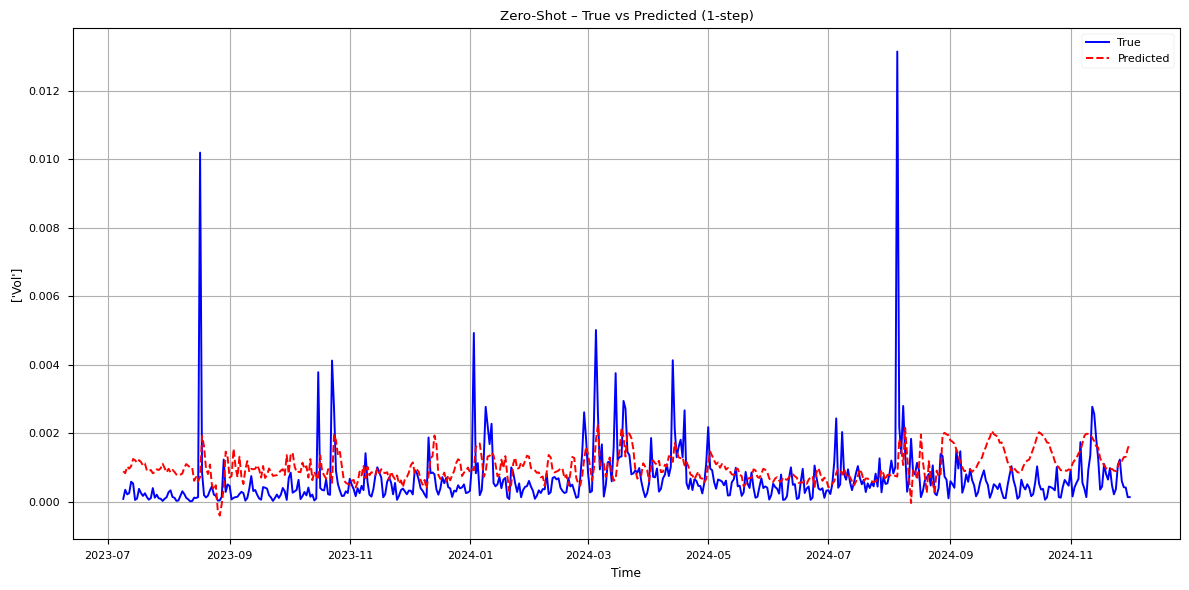

In [9]:
print("Avaliando modelo zero shot...")
forecast_dates_zeroshot, results_zeroshot, labels_zeroshot, preds_zeroshot = evaluate_and_visualize_zero(
    model=model_zero,
    test_dataset=test_ds_zero,
    tsp=tsp_zero,
    test_df=test_df_zero,
    timestamp_col=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    context_length=512,
    forecast=96,
    model_name="Zero-Shot",
)


=== Zero-Shot ===
1-step metrics:
MSE: 1.143859e-06
MAE: 6.191842e-04
RMSE: 1.069514e-03
MAPE: 2.787403e+02

Merged (1-step + tail) metrics:
MSE: 1.105572e-06
MAE: 6.572561e-04
RMSE: 1.051462e-03
MAPE: 2.867808e+02


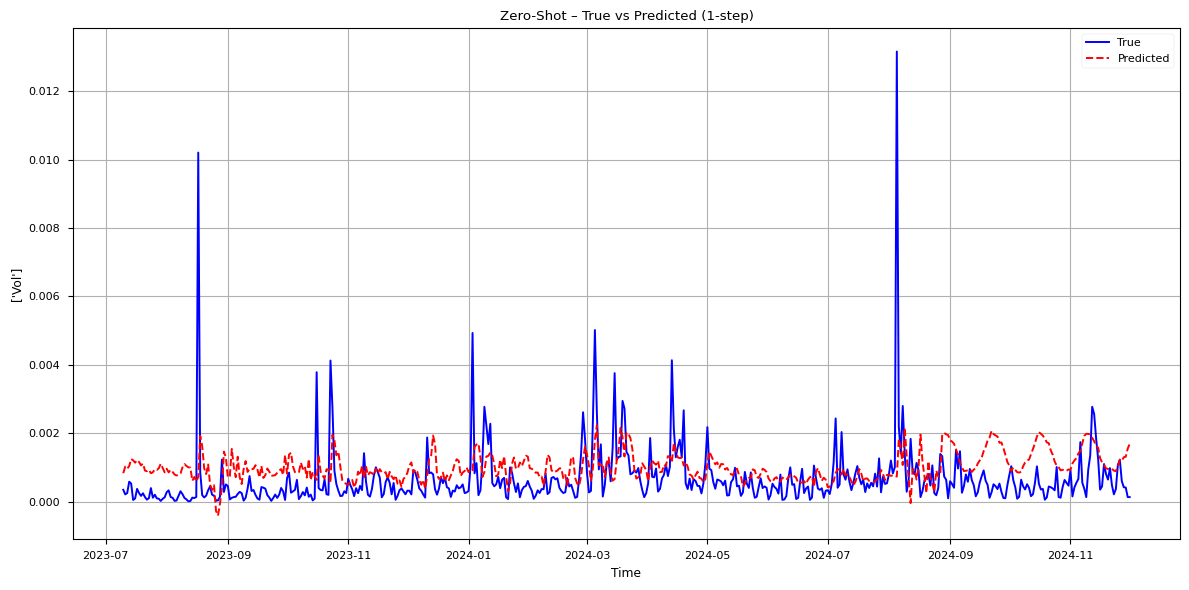

In [10]:
forecast_dates_zeroshot_5, results_zeroshot_5, labels_zeroshot_5, preds_zeroshot_5 = evaluate_and_visualize_zero(
    model=model_zero,
    test_dataset=test_ds_zero_5,
    tsp=tsp_zero,
    test_df=test_df_zero_5,
    timestamp_col=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    context_length=512,
    forecast=96,
    model_name="Zero-Shot",
)

Gráfico salvo em: c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\notebooks\..\data\processed\har_predictions.png


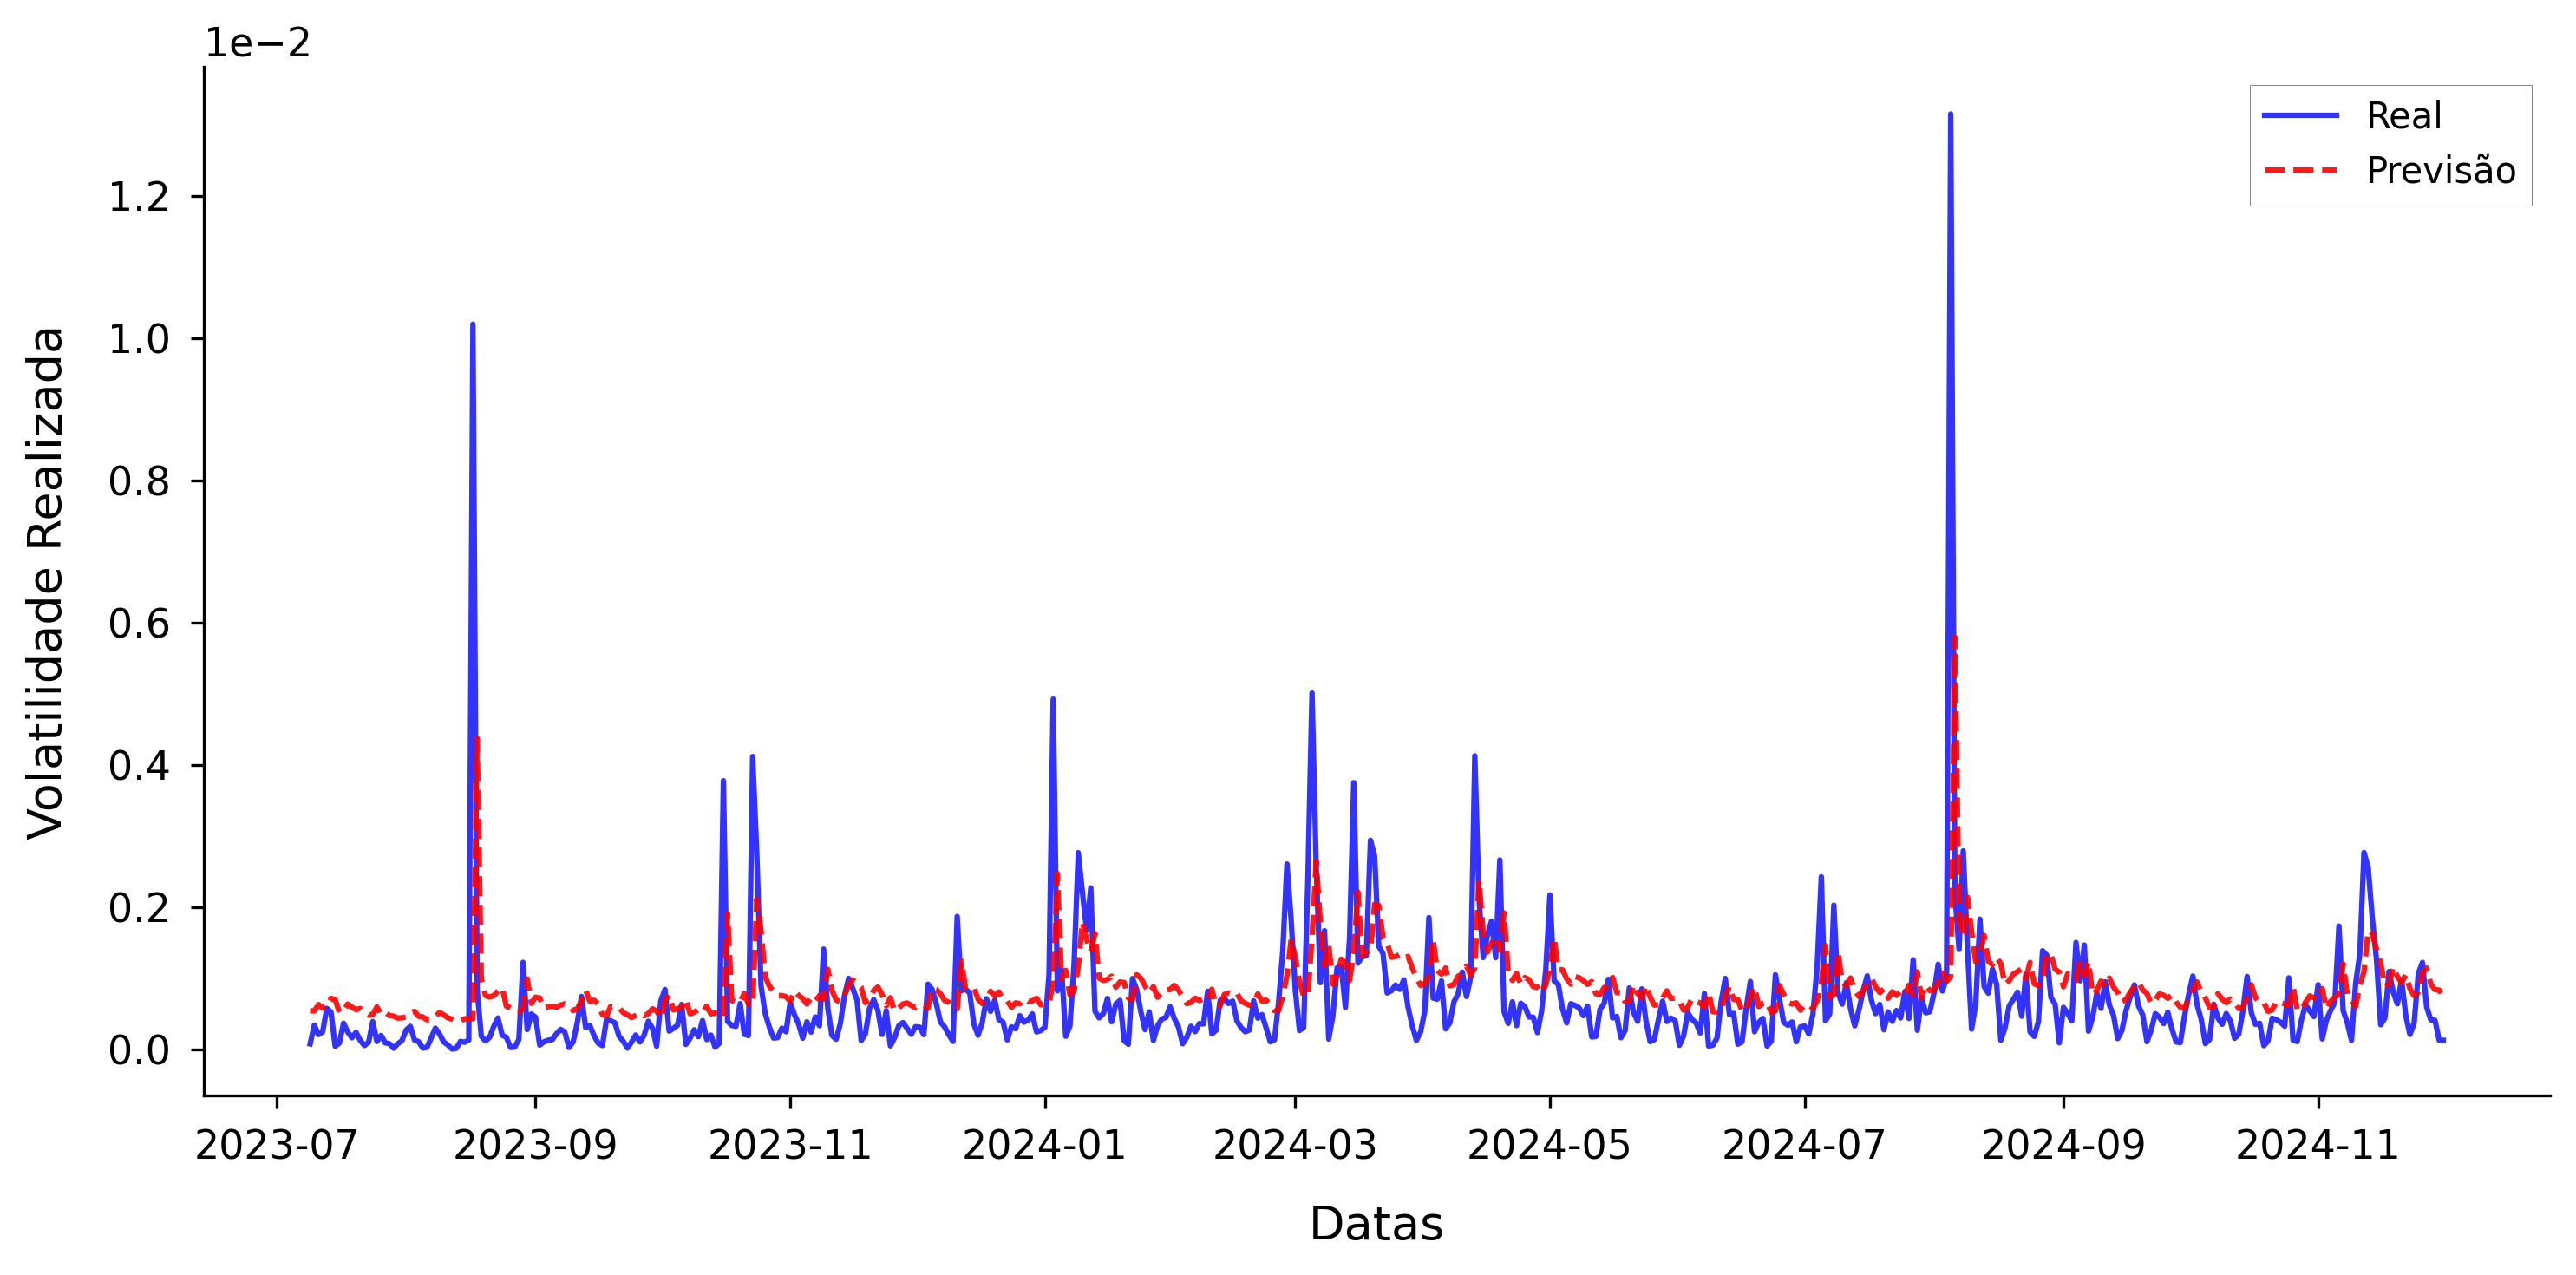

In [21]:
# Configuração do estilo para paper
plt.style.use("seaborn-v0_8-paper")

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Plotar dados com cores profissionais para paper
ax.plot(
    results[0][0], har_labels, label="Real", color="blue", linewidth=1.5, alpha=0.8
)
ax.plot(
    results[0][0],
    har_preds,
    label="Previsão",
    color="red",
    linewidth=1.5,
    linestyle="--",
    alpha=0.9,
)

# Labels e título - fontes maiores
ax.set_xlabel("Datas", fontsize=13, fontweight="normal", labelpad=10)
ax.set_ylabel("Volatilidade Realizada", fontsize=13, fontweight="normal", labelpad=10)

# Legenda
ax.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="gray",
    fontsize=10,
    fancybox=False,
)

# Remover spines superiores e direitas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Ticks maiores
ax.tick_params(axis="both", which="major", labelsize=11)

# Formatar eixo Y para notação científica padronizada
ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
# Aumentar tamanho da notação científica (expoente)
ax.yaxis.get_offset_text().set_fontsize(11)

# Ajustar espaçamento
plt.tight_layout()
from pathlib import Path
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "har_predictions.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Gráfico salvo em: {output_path.absolute()}")
plt.show()

Gráfico salvo em: c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\notebooks\..\data\processed\modelos_comparacao_2x2.png


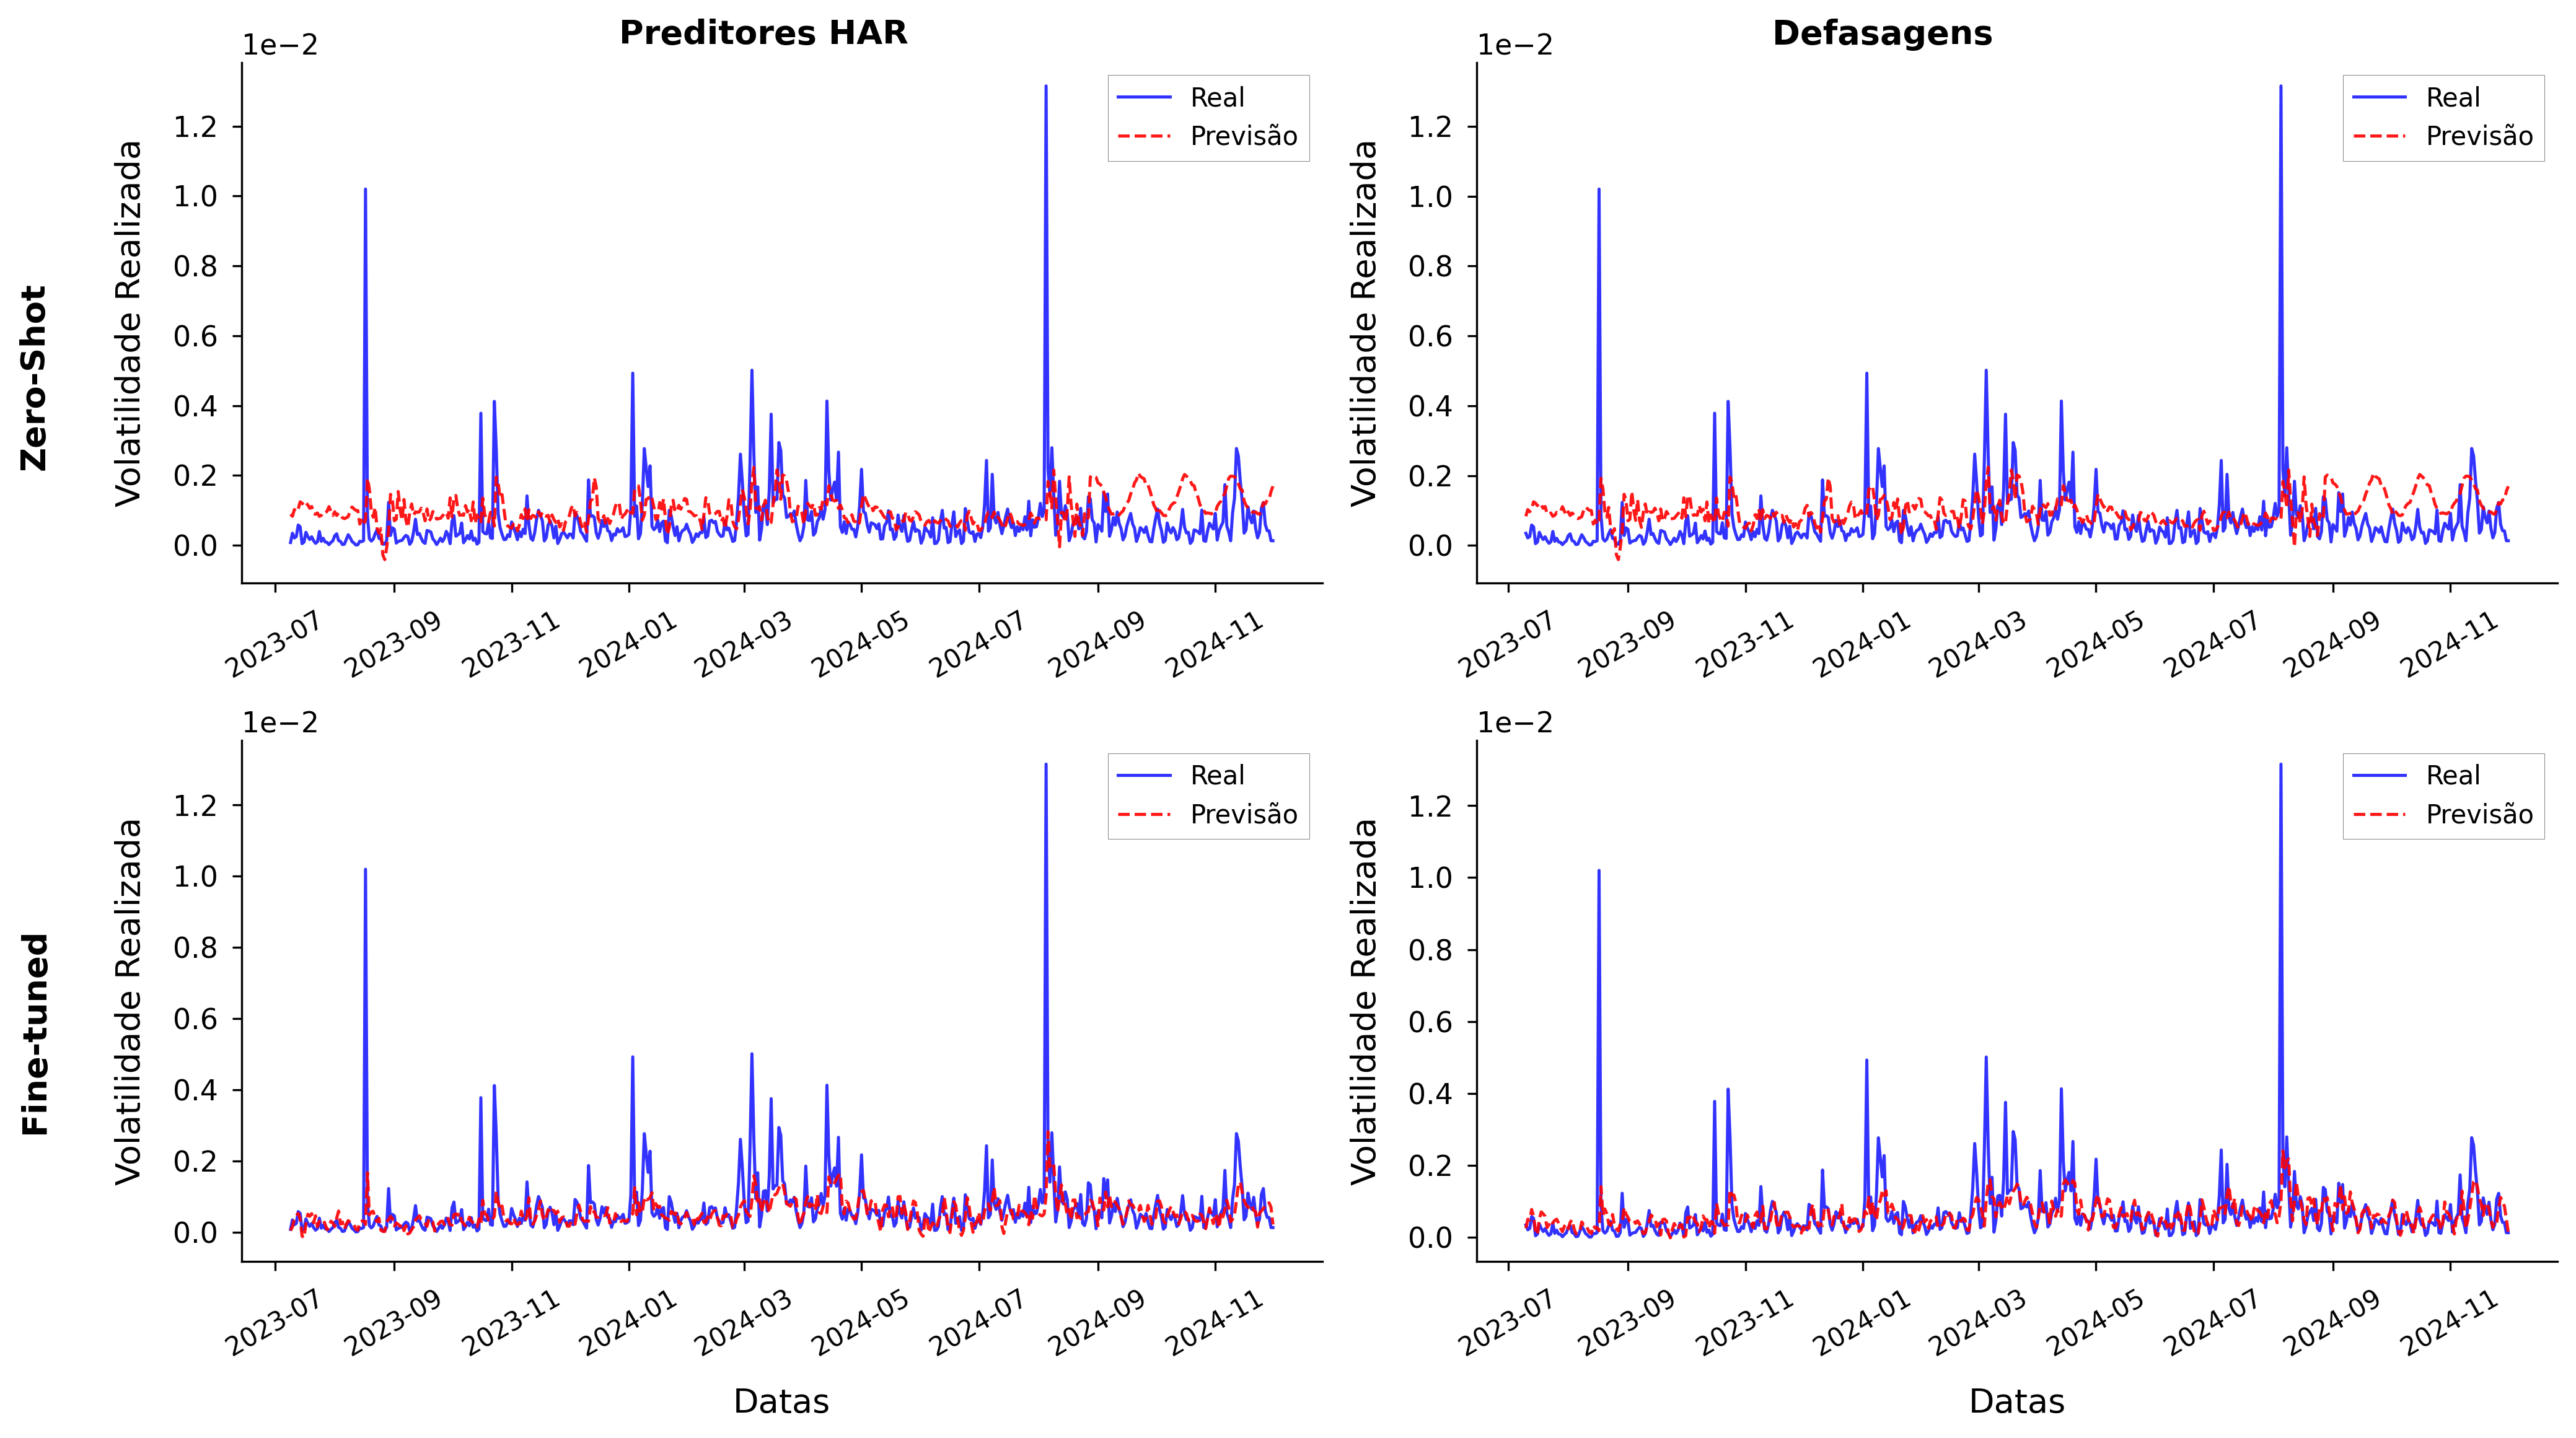

In [20]:
# Criar subplot 2x2 comparando modelos
# Linhas: Zero-shot vs Ajuste Fino
# Colunas: HAR (lags=3, use_mean_features=True) vs Defasagens (lags=5, use_mean_features=False)

plt.style.use("seaborn-v0_8-paper")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=300)

# Dados dos modelos
models_data = {
    'zero_har': (forecast_dates_zeroshot, labels_zeroshot, preds_zeroshot, ""),
    'zero_lag': (forecast_dates_zeroshot_5, labels_zeroshot_5, preds_zeroshot_5, ""),
    'fine_har': (results[0][0], results[0][2], results[0][3], ""),
    'fine_lag': (results[1][0], results[1][2], results[1][3], ""),
}

# Configurar cada subplot
positions = [
    (0, 0, 'zero_har'),
    (0, 1, 'zero_lag'),
    (1, 0, 'fine_har'),
    (1, 1, 'fine_lag')
]

for row, col, key in positions:
    ax = axes[row, col]
    
    if models_data[key] is not None:
        dates, labels, preds, title = models_data[key]
        
        labels, preds = labels, preds

        # Plotar com cores profissionais para paper
        ax.plot(dates, labels, label="Real", color="blue", linewidth=1.2, alpha=0.8)
        ax.plot(dates, preds, label="Previsão", color="red", linewidth=1.2, linestyle="--", alpha=0.9)
        
        # Configurações - fontes maiores
        if row != 0:
            ax.set_xlabel("Datas", fontsize=13, labelpad=10)
        else:
            ax.set_xlabel("")
        ax.set_ylabel("Volatilidade Realizada", fontsize=13, labelpad=10)
        
        # Legenda
        ax.legend(loc='best', frameon=True, framealpha=0.95, edgecolor='gray', 
                  fontsize=10, fancybox=False)
        
        # Remover spines superiores e direitas
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Ticks maiores
        ax.tick_params(axis='both', which='major')
        ax.tick_params(axis='x', rotation=30, labelsize=10)
        ax.tick_params(axis='y', labelsize=11)
        
        # Formatar eixo Y
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
        # Aumentar tamanho da notação científica (expoente)
        ax.yaxis.get_offset_text().set_fontsize(11)
    else:
        ax.text(0.5, 0.5, f"{key} não disponível", 
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

# Adicionar títulos das colunas no topo
fig.text(0.30, 0.95, 'Preditores HAR', ha='center', va='center', fontsize=13, fontweight='bold')
fig.text(0.73, 0.95, 'Defasagens', ha='center', va='center', fontsize=13, fontweight='bold')

# Adicionar títulos das linhas à esquerda
fig.text(0.02, 0.72, 'Zero-Shot', ha='center', va='center', rotation=90, 
         fontsize=13, fontweight='bold')
fig.text(0.02, 0.28, 'Fine-tuned', ha='center', va='center', rotation=90, 
         fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0.04, 0, 1, 0.97])  # Ajustar para dar espaço aos labels

# Salvar figura
from pathlib import Path
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "modelos_comparacao_2x2.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Gráfico salvo em: {output_path.absolute()}")

plt.show()

## Visualizações Comparativas dos Modelos

Nesta seção, comparamos os 4 modelos através de diferentes métricas e análises de erro.

Gráfico salvo em: c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\notebooks\..\data\processed\metricas_comparacao.png


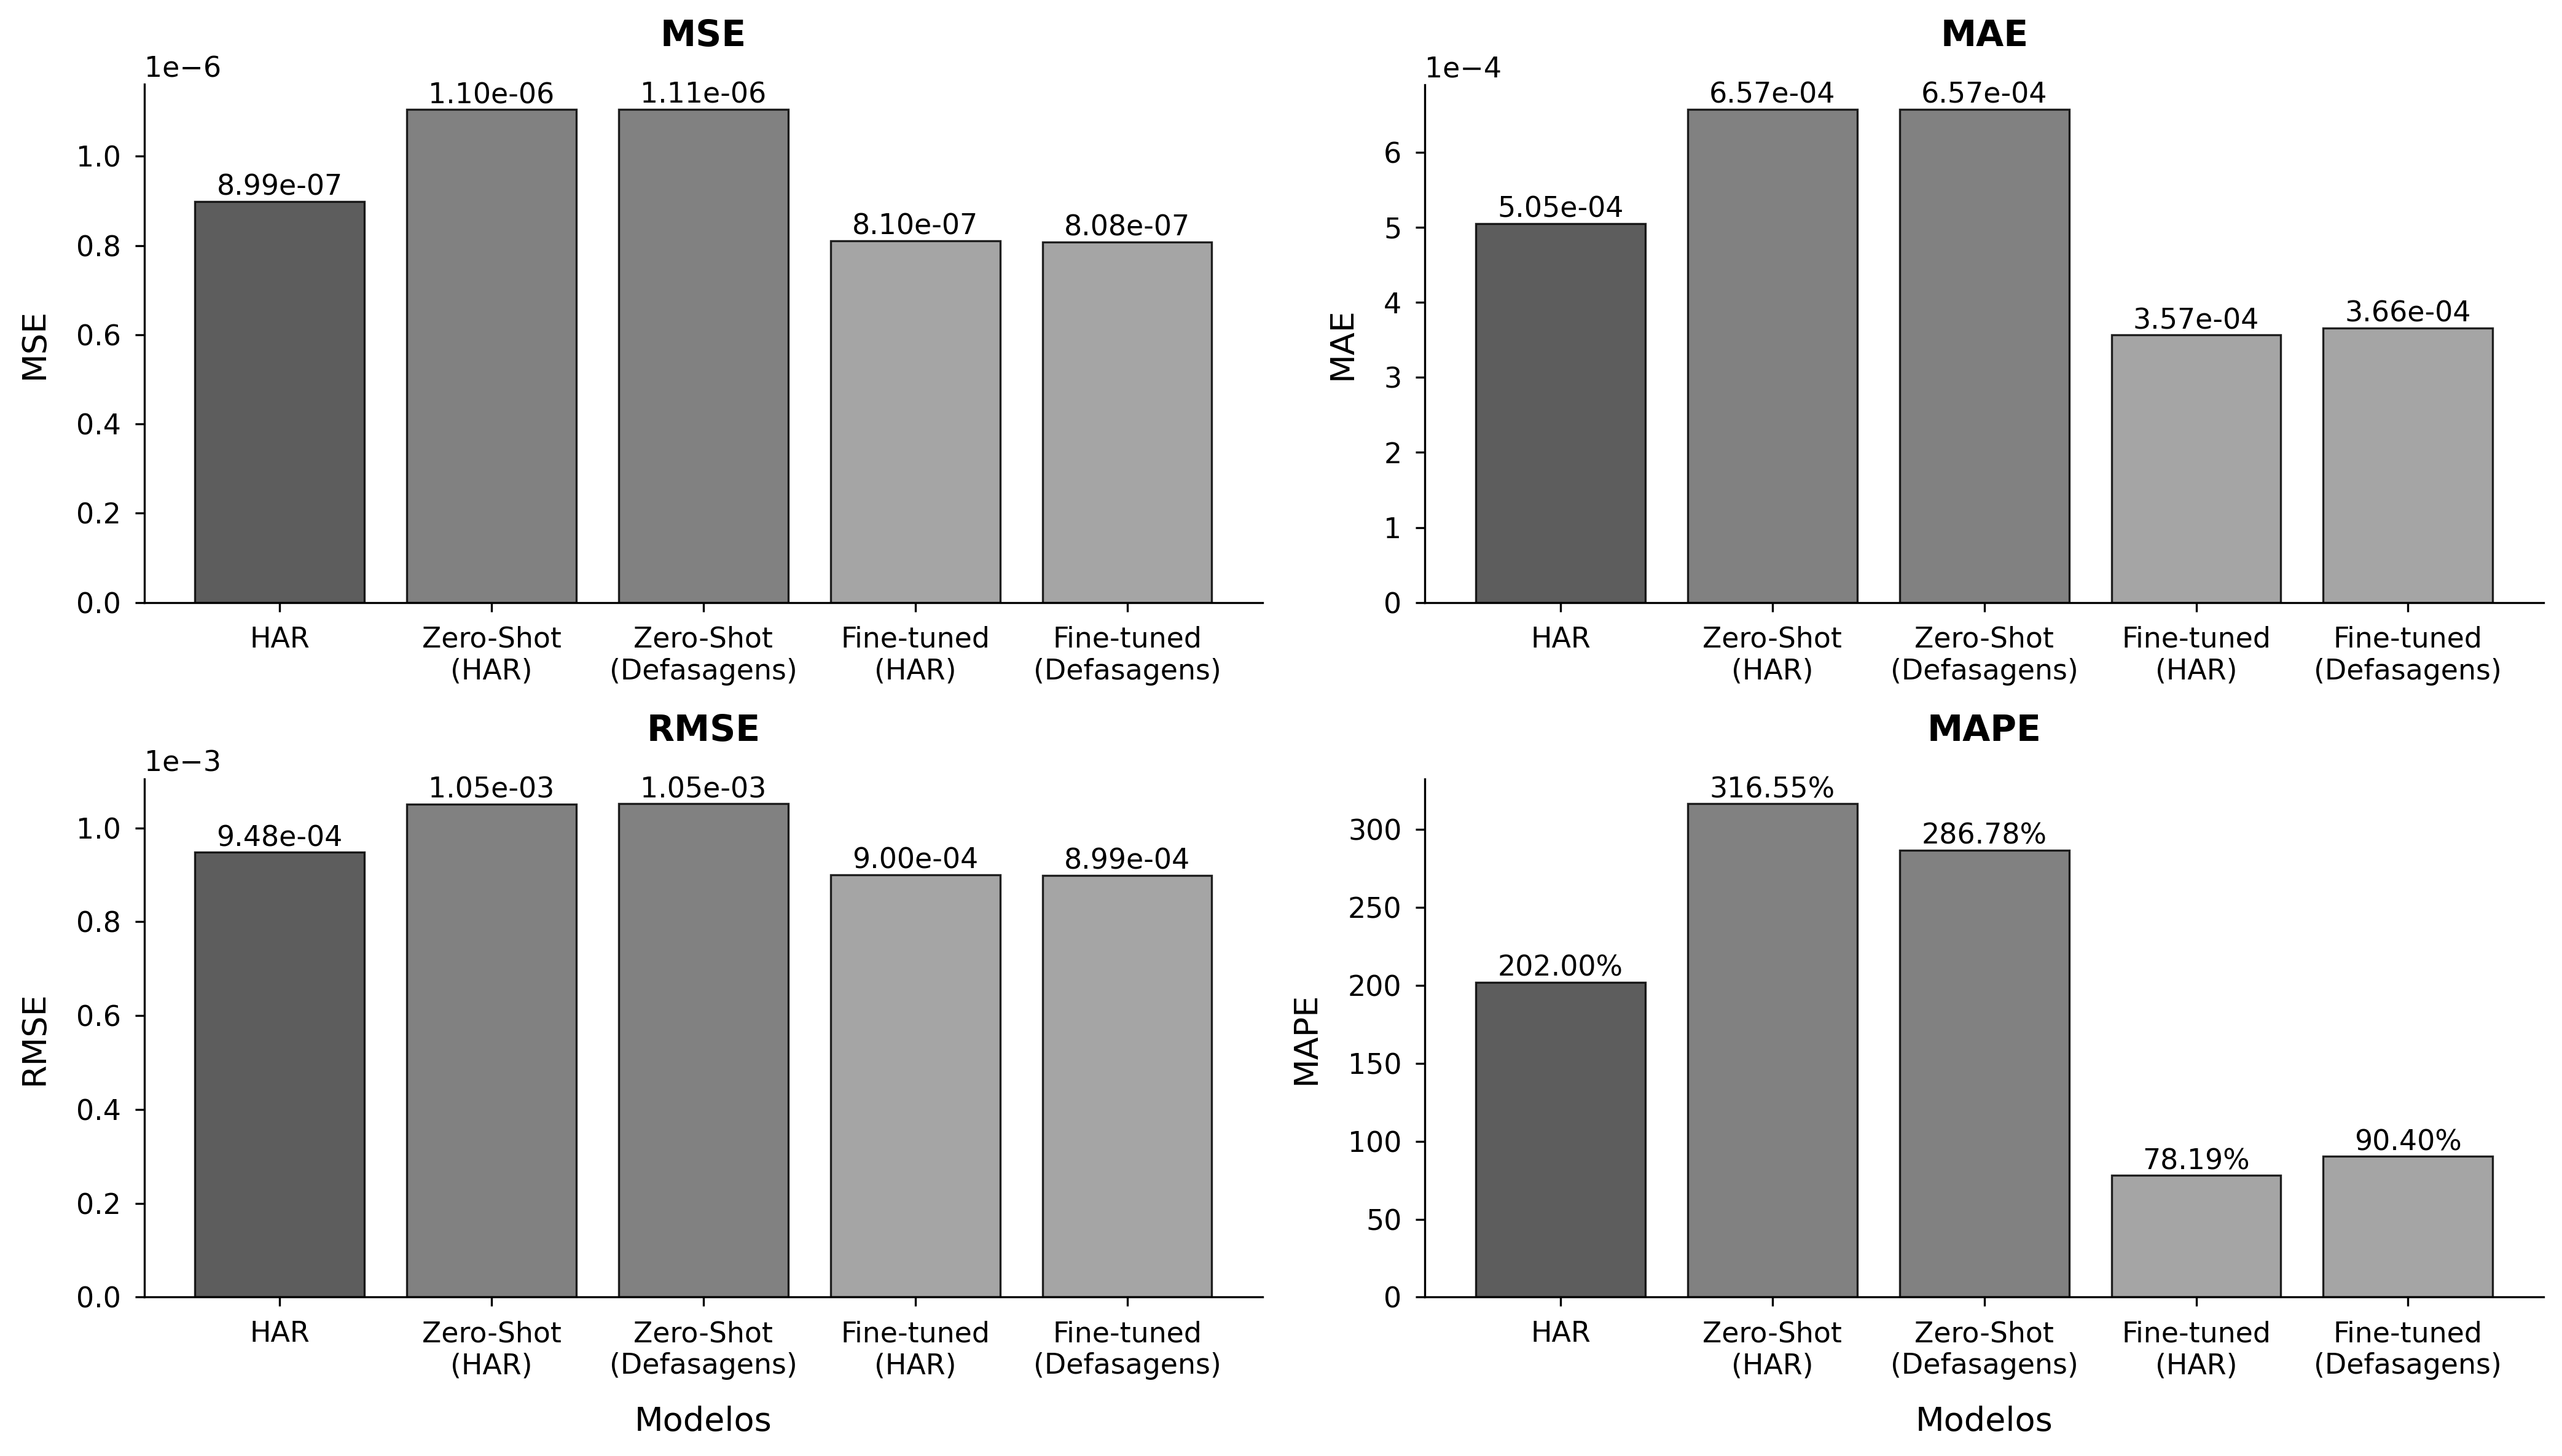

In [ ]:
# 1. Gráfico de Barras de Métricas
# Comparar MSE, MAE, RMSE e MAPE de todos os 5 modelos

plt.style.use("seaborn-v0_8-paper")

# Extrair métricas de todos os modelos
models_metrics = {
    'HAR': har_metrics,
    'Zero-Shot\n(Preditores HAR)': results_zeroshot['metrics_full'],
    'Zero-Shot\n(Defasagens)': results_zeroshot_5['metrics_full'],
    'Fine-tuned\n(Preditores HAR)': results[0][1],
    'Fine-tuned\n(Defasagens)': results[1][1],
}

# Preparar dados para o gráfico
metrics_names = ['MSE', 'MAE', 'RMSE', 'MAPE']
model_names = list(models_metrics.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=300)
axes = axes.flatten()

# Paleta profissional para paper acadêmico
# Escala de cinza que funciona bem em P&B
colors = ['#404040', '#6B6B6B', '#6B6B6B', '#969696', '#969696']

for idx, metric in enumerate(metrics_names):
    ax = axes[idx]
    values = [models_metrics[model][metric] for model in model_names]
    
    # Barras com bordas bem definidas
    bars = ax.bar(range(len(model_names)), values, color=colors, 
                   alpha=0.85, edgecolor='black', linewidth=0.8)
    
    # Configurações - fontes maiores
    if idx > 1:
        ax.set_xlabel('Modelos', fontsize=13, labelpad=10)
    else:
        ax.set_xlabel('')
    ax.set_ylabel(metric, fontsize=13, labelpad=10)
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, fontsize=10, rotation=0)
    
    # Adicionar valores no topo das barras
    for i, (bar, value) in enumerate(zip(bars, values)):
        height = bar.get_height()
        # Formatar MAPE como porcentagem
        if metric == 'MAPE':
            value_text = f'{value:.2f}%'
        else:
            value_text = f'{value:.2e}'
        
        ax.text(bar.get_x() + bar.get_width()/2., height,
                value_text,
                ha='center', va='bottom', fontsize=11, fontweight='normal')
    
    # Remover spines superiores e direitas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Ticks maiores
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Formatar eixo Y - não usar notação científica para MAPE
    if metric != 'MAPE':
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
        # Aumentar tamanho da notação científica (expoente)
        ax.yaxis.get_offset_text().set_fontsize(11)

plt.tight_layout()

# Salvar figura
output_path = Path("../data/processed") / "metricas_comparacao.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Gráfico salvo em: {output_path.absolute()}")

plt.show()